# Knowledge-Infused Multimodal Learning — Hands-On (v2)
### ICWSM 2026 Tutorial | Trilok Padhi, Agnik Saha & Ugur Kursuncu
#### Use-case: AI-powered Marketing Ads Intelligence

Two self-contained parts — run them in order.

| Part | What we build | Models used |
|------|--------------|-------------|
| **1 — KID-VLM** | Train a knowledge-distillation model on real social media data for **brand safety** classification | `sentence-transformers` (teacher, pre-trained), custom MLP (student) |
| **2 — Ad Intelligence Agent** | KG-backed memory over marketing AI research + live ad image analysis + agentic Q&A | `Qwen3-VL-8B` via OpenRouter · `gpt-4o-mini` via OpenAI |

> **Cost:** Part 2 makes ~10 small API calls. Estimated total < $0.01 on OpenRouter + OpenAI.  
> **Keys:** Loaded from `keys.txt` 

In [53]:
%pip install -q torch sentence-transformers datasets openai networkx matplotlib scikit-learn pillow requests

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os

# Read API keys from keys.txt in the same folder as this notebook.
# keys.txt is in .gitignore — never commit it to version control.
with open("keys.txt") as f:
    for line in f:
        line = line.strip()
        if "=" in line and not line.startswith("#"):
            k, v = line.split("=", 1)
            os.environ[k.strip()] = v.strip()

print("Keys loaded from keys.txt ✓")
print(f"  OPENROUTER_API_KEY: ...{os.environ['OPENROUTER_API_KEY'][-6:]}")
print(f"  OPENAI_API_KEY:     ...{os.environ['OPENAI_API_KEY'][-6:]}")

Keys loaded from keys.txt ✓
  OPENROUTER_API_KEY: ...6de60b
  OPENAI_API_KEY:     ...pmtPIA


In [2]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, networkx as nx
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import random, math, base64, io, textwrap
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont

random.seed(42); np.random.seed(42); torch.manual_seed(42)
print("Imports OK")

Imports OK


---
# Part 1 — KID-VLM: Knowledge Distillation for Brand Safety Classification

**Paper:** [Just KIDDIN' (ACL Findings 2025)](https://aclanthology.org/2025.findings-acl.1184v2.pdf) — Garg, Padhi, Jain, Kursuncu, Kumaraguru  
**Repo:** https://github.com/SWAN-AI/Knowledge-Infused-Distilled-VLMs

---

## The marketing problem

**Brand safety** — preventing your ad from appearing next to harmful or toxic content — is one of the hardest challenges in programmatic advertising.  
Large VLMs understand cultural nuance (sarcasm, dog-whistles, coded language), but cost too much for real-time bidding (RTB) latency budgets.  
Small classifiers are fast enough, but miss context that would obviously disqualify placement.

**KID-VLM bridges the gap: the small model inherits the large model's world knowledge.**

---

## Step 1 — Knowledge Infusion (KI): building the subgraph

```
Ad placement candidate (URL + surrounding text)
    ↓  VLM caption of the page context (LLaVA)
"Article about protest with divisive imagery"
    ↓  Entity extraction  (spaCy + concept.txt matcher patterns)
Seed nodes: {protest, violence, politics, brand_risk, ...}
    ↓  Hop-1 / Hop-2 expansion in ConceptNet  (concept.txt)
    ↓  Relevancy scoring with MiniLM  →  prune to top-500 nodes
    ↓  TranSE embedding per node  (glove.transe.sgd.ent.npy)
    ↓  R-GCN processes the subgraph  →  graph embedding  g_i
Final pruned subgraph G_i  (per meme / ad placement)
```

## Step 2 — Knowledge Distillation (KD): teacher → student

$$\mathcal{L} = \underbrace{\mathcal{L}_{CE}(\hat{y}, y)}_{\text{hard labels}} + \lambda \cdot \underbrace{\| \mathbf{s}_i - \mathbf{w}_i^{\text{teacher}} \|^2_2}_{\text{mimic teacher}}$$

| Paper component | Our stand-in |
|-----------------|-------------|
| LLaVA caption teacher | `all-MiniLM-L6-v2` SentenceTransformer |
| **ConceptNet + TranSE + R-GCN** | **Simulated below — full pipeline, no download needed** |
| Student fusion | Small MLP with a KD head |

---
## KID-VLM Step 1 — ConceptNet subgraph pipeline (simulated offline)

In the paper the files used are:
- `Entity Extraction/concept.txt` — ConceptNet v5 triples  `(head, relation, tail, weight)`
- `glove.transe.sgd.ent.npy` — 100-dim TranSE embeddings for every ConceptNet node

We simulate both files in memory below so you can run the **exact same pipeline** without downloading 10 GB of ConceptNet.

ConceptNet (simulated): 30 nodes, 55 triples loaded.
TranSE embeddings: 100-dim per node  (paper: glove.transe.sgd.ent.npy)

Caption:  "Our AI says the ad placement is brand-safe, but the ad ran next to toxic conspiracy content"
Seed entities (matched to ConceptNet):  ['conspiracy']

  Hop 1: +6 candidate nodes
  Hop 2: +0 candidate nodes

Raw subgraph: 7 nodes, 6 edges

Relevancy-pruned subgraph (top-20): 7 nodes, 6 edges
Top-5 nodes by MiniLM relevance:
  conspiracy                 score=0.338
  dangerous                  score=0.295
  propaganda                 score=0.290
  harm                       score=0.268
  fake_news                  score=0.248

TranSE feature matrix X: torch.Size([7, 100])  (paper: loaded from glove.transe.sgd.ent.npy)
Adjacency matrix A:       torch.Size([7, 7])

R-GCN output H': torch.Size([7, 64])  (node-level representations)
Graph embedding g_i: torch.Size([64])  ← this is the KI contribution to the student
  g_i[:8] = [0.0614052377641201, 0.0, 0.0743

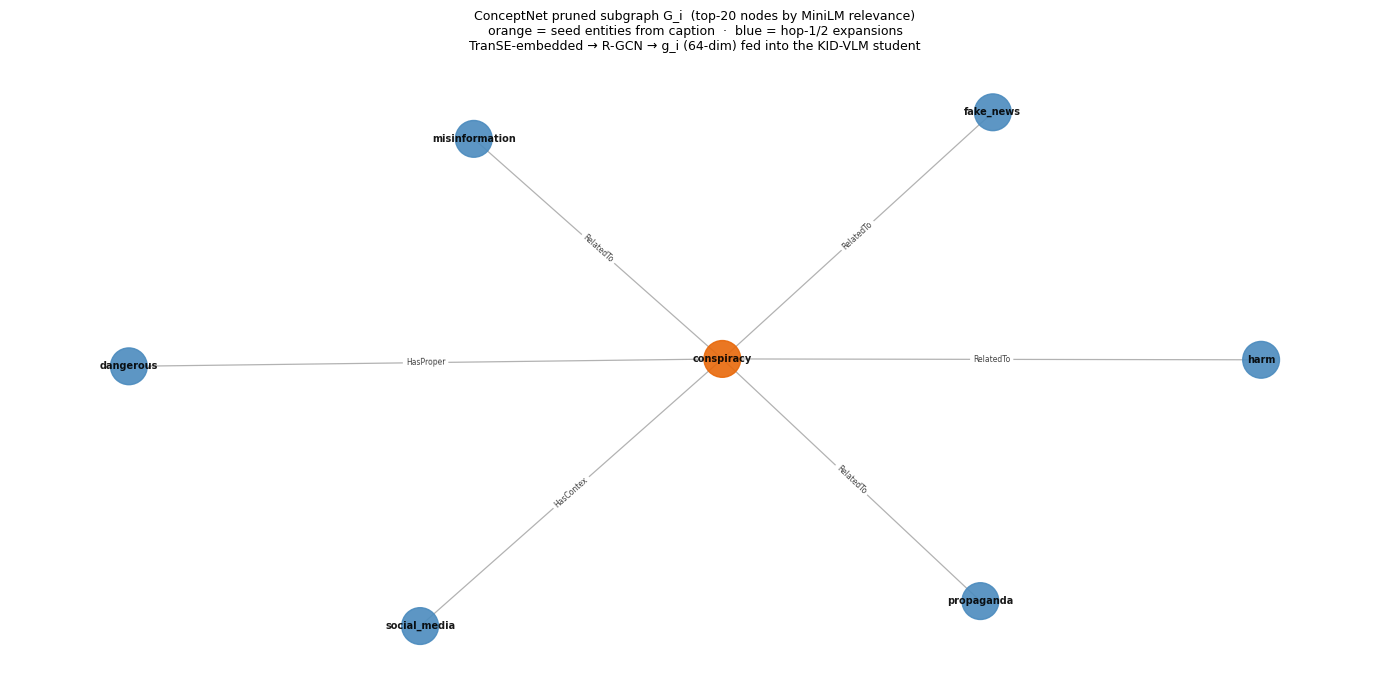

In [ ]:
import torch, torch.nn as nn, networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

torch.manual_seed(0)

# ─────────────────────────────────────────────────────────────────────────────
# Simulated  concept.txt  (ConceptNet v5 triples: head, relation, tail, weight)
# The paper loads this file and builds a lookup: entity → [(relation, tail, w)]
# ─────────────────────────────────────────────────────────────────────────────
CONCEPTNET_TRIPLES = [
    # brand safety seed
    ("brand_safety",      "RelatedTo",   "advertisement",     3.0),
    ("brand_safety",      "RelatedTo",   "content_moderation",3.0),
    ("brand_safety",      "RelatedTo",   "trust",             2.5),
    ("brand_safety",      "Antonym",     "brand_risk",        2.0),
    ("brand_safety",      "UsedFor",     "protecting_brands", 2.0),
    ("brand_safety",      "HasContext",  "programmatic_ads",  2.0),
    # advertisement seed
    ("advertisement",     "RelatedTo",   "brand_safety",      2.5),
    ("advertisement",     "RelatedTo",   "marketing",         3.0),
    ("advertisement",     "RelatedTo",   "audience",          2.5),
    ("advertisement",     "UsedFor",     "promotion",         2.5),
    ("advertisement",     "HasContext",  "media",             2.0),
    ("advertisement",     "RelatedTo",   "revenue",           2.0),
    # toxicity seed
    ("toxicity",          "RelatedTo",   "harm",              3.0),
    ("toxicity",          "RelatedTo",   "hate_speech",       3.0),
    ("toxicity",          "Antonym",     "safety",            2.5),
    ("toxicity",          "HasProperty", "harmful",           2.5),
    ("toxicity",          "RelatedTo",   "content_moderation",2.5),
    ("toxicity",          "RelatedTo",   "misinformation",    2.0),
    # conspiracy seed
    ("conspiracy",        "RelatedTo",   "misinformation",    3.0),
    ("conspiracy",        "RelatedTo",   "harm",              2.5),
    ("conspiracy",        "RelatedTo",   "propaganda",        2.5),
    ("conspiracy",        "HasProperty", "dangerous",         2.0),
    ("conspiracy",        "RelatedTo",   "fake_news",         2.5),
    ("conspiracy",        "HasContext",  "social_media",      2.0),
    # safety seed
    ("safety",            "Antonym",     "danger",            2.5),
    ("safety",            "RelatedTo",   "protection",        3.0),
    ("safety",            "RelatedTo",   "trust",             2.0),
    ("safety",            "UsedFor",     "brand_protection",  2.0),
    ("safety",            "RelatedTo",   "content_filter",    2.0),
    ("safety",            "Antonym",     "toxicity",          2.5),
    # hop-2 expansions
    ("content_moderation","RelatedTo",   "hate_speech",       2.5),
    ("content_moderation","UsedFor",     "platform_safety",   2.5),
    ("content_moderation","RelatedTo",   "ai_classifier",     2.0),
    ("hate_speech",       "RelatedTo",   "toxicity",          3.0),
    ("hate_speech",       "HasContext",  "social_media",      2.0),
    ("hate_speech",       "RelatedTo",   "harm",              2.5),
    ("misinformation",    "RelatedTo",   "fake_news",         2.5),
    ("misinformation",    "HasContext",  "social_media",      2.0),
    ("misinformation",    "RelatedTo",   "propaganda",        2.0),
    ("marketing",         "RelatedTo",   "brand_safety",      2.0),
    ("marketing",         "RelatedTo",   "audience",          2.5),
    ("marketing",         "UsedFor",     "revenue",           2.0),
    ("propaganda",        "RelatedTo",   "misinformation",    2.5),
    ("propaganda",        "HasProperty", "manipulative",      2.0),
    ("fake_news",         "RelatedTo",   "misinformation",    3.0),
    ("fake_news",         "HasContext",  "social_media",      2.0),
    ("harm",              "Antonym",     "safety",            2.5),
    ("harm",              "RelatedTo",   "toxicity",          2.5),
    ("platform_safety",   "RelatedTo",   "content_moderation",2.0),
    ("ai_classifier",     "UsedFor",     "content_moderation",2.0),
    ("ai_classifier",     "RelatedTo",   "brand_safety",      2.0),
    ("trust",             "RelatedTo",   "brand_safety",      2.0),
    ("audience",          "RelatedTo",   "advertisement",     2.0),
    ("programmatic_ads",  "RelatedTo",   "brand_safety",      2.5),
    ("programmatic_ads",  "RelatedTo",   "advertisement",     2.5),
]

# Build adjacency lookup  (simulates loading concept.txt into memory)
CN_LOOKUP = defaultdict(list)
for h, rel, t, w in CONCEPTNET_TRIPLES:
    CN_LOOKUP[h].append((rel, t, w))
    CN_LOOKUP[t].append((rel, h, w))   # undirected for subgraph expansion

ALL_CN_NODES = sorted(set(h for h, *_ in CONCEPTNET_TRIPLES) |
                      set(t for _, __, t, ___ in CONCEPTNET_TRIPLES))

# ─────────────────────────────────────────────────────────────────────────────
# Simulated  glove.transe.sgd.ent.npy  (100-dim TranSE embedding per node)
# Paper loads:  transe_emb = np.load("glove.transe.sgd.ent.npy")
# We generate reproducible random vectors (same shape & dimension)
# ─────────────────────────────────────────────────────────────────────────────
TRANSE_DIM = 100
_rng = torch.Generator(); _rng.manual_seed(42)
TRANSE_EMBEDDINGS = {
    node: torch.randn(TRANSE_DIM, generator=_rng)
    for node in ALL_CN_NODES
}
print(f"ConceptNet (simulated): {len(ALL_CN_NODES)} nodes, "
      f"{len(CONCEPTNET_TRIPLES)} triples loaded.")
print(f"TranSE embeddings: {TRANSE_DIM}-dim per node  "
      f"(paper: glove.transe.sgd.ent.npy)\n")

# ─────────────────────────────────────────────────────────────────────────────
# Step 1a — Entity extraction from meme caption
# Paper: spaCy + matcher_patterns.json keyed against concept.txt vocabulary
# ─────────────────────────────────────────────────────────────────────────────
CAPTION = ("Our AI says the ad placement is brand-safe, "
           "but the ad ran next to toxic conspiracy content")

def extract_seed_entities(caption: str, cn_vocab: set) -> list:
    """Match multi-word + single-word phrases against ConceptNet vocabulary."""
    tokens = caption.lower().replace(",", "").replace(".", "").split()
    found = set()
    # multi-word first (bigrams)
    for i in range(len(tokens) - 1):
        phrase = tokens[i] + "_" + tokens[i+1]
        if phrase in cn_vocab:
            found.add(phrase)
    # single words
    for tok in tokens:
        if tok in cn_vocab:
            found.add(tok)
    return sorted(found)

CN_VOCAB = set(ALL_CN_NODES)
seeds = extract_seed_entities(CAPTION, CN_VOCAB)
print(f"Caption:  \"{CAPTION}\"")
print(f"Seed entities (matched to ConceptNet):  {seeds}\n")

# ─────────────────────────────────────────────────────────────────────────────
# Step 1b — Hop-1 / Hop-2 graph expansion  
# ─────────────────────────────────────────────────────────────────────────────
def expand_subgraph(seeds: list, hops: int = 2) -> nx.Graph:
    G = nx.Graph()
    frontier = set(seeds)
    for hop in range(hops):
        next_frontier = set()
        for node in frontier:
            for rel, neighbor, w in CN_LOOKUP.get(node, []):
                G.add_node(node)
                G.add_node(neighbor)
                if G.has_edge(node, neighbor):
                    G[node][neighbor]["weight"] += w
                else:
                    G.add_edge(node, neighbor, relation=rel, weight=w)
                next_frontier.add(neighbor)
        frontier = next_frontier - set(G.nodes())
        print(f"  Hop {hop+1}: +{len(next_frontier)} candidate nodes")
    return G

G_raw = expand_subgraph(seeds, hops=2)
print(f"\nRaw subgraph: {G_raw.number_of_nodes()} nodes, "
      f"{G_raw.number_of_edges()} edges\n")

# ─────────────────────────────────────────────────────────────────────────────
# Step 1c — Relevancy scoring + pruning  (paper: RelKMG/RelScoreMiniLM.py)
# MiniLM cosine similarity of each node label to the original caption
# ─────────────────────────────────────────────────────────────────────────────
caption_emb = teacher_sbert.encode(CAPTION, convert_to_tensor=True)
node_labels  = list(G_raw.nodes())
node_embs    = teacher_sbert.encode(
    [n.replace("_", " ") for n in node_labels], convert_to_tensor=True
)
relevance = nn.functional.cosine_similarity(
    node_embs, caption_emb.unsqueeze(0).expand_as(node_embs)
).tolist()

node_scores = dict(zip(node_labels, relevance))
TOP_K = 20   # paper uses 250 / 500 / 750; we use 20 for readability
top_nodes = sorted(node_scores, key=node_scores.get, reverse=True)[:TOP_K]
G_pruned  = G_raw.subgraph(top_nodes).copy()

print(f"Relevancy-pruned subgraph (top-{TOP_K}): "
      f"{G_pruned.number_of_nodes()} nodes, {G_pruned.number_of_edges()} edges")
print(f"Top-5 nodes by MiniLM relevance:")
for n in sorted(node_scores, key=node_scores.get, reverse=True)[:5]:
    print(f"  {n:<25}  score={node_scores[n]:.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 1d — TranSE node embedding matrix  (paper: makeGraphs.py)
# glove.transe.sgd.ent.npy maps entity → 100-dim vector
# ─────────────────────────────────────────────────────────────────────────────
pruned_nodes = list(G_pruned.nodes())
node2idx     = {n: i for i, n in enumerate(pruned_nodes)}
X_nodes      = torch.stack([TRANSE_EMBEDDINGS[n] for n in pruned_nodes])  # (N, 100)

# Adjacency matrix (normalised, for R-GCN message passing)
N = len(pruned_nodes)
A = torch.zeros(N, N)
for u, v, d in G_pruned.edges(data=True):
    i, j = node2idx[u], node2idx[v]
    A[i, j] = d.get("weight", 1.0)
    A[j, i] = d.get("weight", 1.0)
deg = A.sum(dim=1, keepdim=True).clamp(min=1)
A_norm = A / deg   # degree-normalised

print(f"\nTranSE feature matrix X: {X_nodes.shape}  "
      f"(paper: loaded from glove.transe.sgd.ent.npy)")
print(f"Adjacency matrix A:       {A_norm.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 1e — R-GCN  (paper: hateclipperModel_rgcn_caption_llava_distil.py)
# 1-layer simplified R-GCN:  H' = ReLU( A_norm · X · W )
# Produces graph embedding  g_i = mean_pool(H')
# ─────────────────────────────────────────────────────────────────────────────
RGCN_OUT_DIM = 64   # matches HIDDEN_DIM used in the student model

torch.manual_seed(0)
W_rgcn = nn.Linear(TRANSE_DIM, RGCN_OUT_DIM, bias=False)
with torch.no_grad():
    H_prime = torch.relu(A_norm @ X_nodes @ W_rgcn.weight.T)  # (N, 64)
    g_i     = H_prime.mean(dim=0)                              # (64,) — graph embedding

print(f"\nR-GCN output H': {H_prime.shape}  (node-level representations)")
print(f"Graph embedding g_i: {g_i.shape}  ← this is the KI contribution to the student")
print(f"  g_i[:8] = {g_i[:8].tolist()}")

# ─────────────────────────────────────────────────────────────────────────────
# Visualise the pruned subgraph
# ─────────────────────────────────────────────────────────────────────────────
seed_set    = set(seeds)
node_colors = ["#E8680A" if n in seed_set else "#4B8BBE" for n in G_pruned.nodes()]
edge_labels = {(u, v): d.get("relation","")[:9] for u, v, d in G_pruned.edges(data=True)}

plt.figure(figsize=(14, 7))
pos = nx.spring_layout(G_pruned, seed=7, k=2.2)
nx.draw_networkx(G_pruned, pos, node_color=node_colors, node_size=700,
                 font_size=7, font_weight="bold",
                 edge_color="#aaaaaa", width=0.9, alpha=0.9)
nx.draw_networkx_edge_labels(G_pruned, pos, edge_labels=edge_labels,
                              font_size=5.5, alpha=0.75)
plt.title(
    f"ConceptNet pruned subgraph G_i  (top-{TOP_K} nodes by MiniLM relevance)\n"
    "orange = seed entities from caption  ·  blue = hop-1/2 expansions\n"
    "TranSE-embedded → R-GCN → g_i (64-dim) fed into the KID-VLM student",
    fontsize=9
)
plt.axis("off"); plt.tight_layout(); plt.show()

In [3]:
# ── Load real data: tweet_eval hate detection ────────────────────────────────
# tweet_eval is a Cardiff NLP benchmark of English tweets.
# The "hate" split is binary: 0 = not hateful, 1 = hateful.
# HuggingFace moved it to "cardiffnlp/tweet_eval" (namespace/name format required).
from datasets import load_dataset

print("Loading cardiffnlp/tweet_eval (hate split) …")
ds = load_dataset("cardiffnlp/tweet_eval", "hate", split="train", trust_remote_code=True)

# 500 examples → fast CPU training
ds = ds.shuffle(seed=42).select(range(500))

texts  = ds["text"]
labels = ds["label"]

print(f"Loaded {len(texts)} tweets")
print(f"Label distribution: {sum(labels)} hateful / {len(labels)-sum(labels)} non-hateful")
print("\nSample tweets:")
for t, l in zip(texts[:3], labels[:3]):
    tag = "HATE" if l else "OK  "
    print(f"  [{tag}] {t[:90]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cardiffnlp/tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading cardiffnlp/tweet_eval (hate split) …
Loaded 500 tweets
Label distribution: 201 hateful / 299 non-hateful

Sample tweets:
  [HATE] @user Hard to figure which was the more hysterical woman, Cory Booker or Kamala Harris
  [OK  ] Friend- you really need to chill on the drinking and sleeping around Me-
  [OK  ] Great example as an immigrant and woman CEO, Indra Nooyi (Indian-American): ‘Pepsi’s first


In [4]:
# ── Teacher: real pre-trained SentenceTransformer ────────────────────────────
# all-MiniLM-L6-v2 is 22M params, trained on 1B sentence pairs.
# It produces 384-d embeddings that capture semantic meaning.
# This is our "frozen teacher" — we never update its weights.
from sentence_transformers import SentenceTransformer

print("Loading teacher model (all-MiniLM-L6-v2) …")
teacher_sbert = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding tweets with teacher …")
teacher_embeddings = teacher_sbert.encode(
    texts, batch_size=64, show_progress_bar=True,
    convert_to_tensor=True, normalize_embeddings=True
)  # shape: (500, 384)

# Detect device — MPS on Apple Silicon, CUDA on GPU machines, CPU otherwise
DEVICE   = teacher_embeddings.device
y_tensor = torch.tensor(labels, dtype=torch.long).to(DEVICE)

print(f"\nTeacher embedding shape : {teacher_embeddings.shape}")
print(f"Device                  : {DEVICE}")
print(f"Each tweet → 384-d dense vector (these are the 'dark knowledge' targets).")

Loading teacher model (all-MiniLM-L6-v2) …


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding tweets with teacher …


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


Teacher embedding shape : torch.Size([500, 384])
Device                  : mps:0
Each tweet → 384-d dense vector (these are the 'dark knowledge' targets).


In [45]:
# ── Student model ─────────────────────────────────────────────────────────────
# The student takes the same 384-d input but compresses it to 64-d first,
# then tries to reconstruct the full 384-d teacher embedding + classify.
# At inference time, only the student runs — no teacher needed.

TEACHER_DIM = 384   # all-MiniLM-L6-v2 output size
HIDDEN_DIM  = 64    # student bottleneck — 6x smaller than teacher
N_CLASSES   = 2     # hate / non-hate
KD_LAMBDA   = 0.5   # balance classification vs distillation

class StudentModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, teacher_dim, n_classes):
        super().__init__()
        # Encoder: compress the input to a small bottleneck representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
        )
        # KD head: project bottleneck back up to teacher's embedding space
        # This is the layer that receives the MSE distillation loss
        self.kd_head = nn.Linear(hidden_dim, teacher_dim)
        # Classifier head: predict hate / non-hate
        self.classifier = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        h    = self.encoder(x)          # small bottleneck representation
        kd   = self.kd_head(h)          # mimicry of teacher's embedding
        logits = self.classifier(h)     # classification
        return kd, logits

student = StudentModel(TEACHER_DIM, HIDDEN_DIM, TEACHER_DIM, N_CLASSES).to(DEVICE)
print(f"Student parameters: {sum(p.numel() for p in student.parameters()):,}")
print(f"Teacher parameters: {sum(p.numel() for p in teacher_sbert.parameters()):,}")
print(f"Compression ratio : {sum(p.numel() for p in teacher_sbert.parameters()) / sum(p.numel() for p in student.parameters()):.0f}×")

Student parameters: 49,858
Teacher parameters: 22,713,216
Compression ratio : 456×


In [46]:
# ── Train the student with CE + KD loss ──────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 64
LR         = 3e-4

# Use teacher embeddings as input features (stand-in for the full VLM encoder)
X = teacher_embeddings   # (500, 384)  — teacher's view of the tweets

# 80/20 train/test split
n_train = 400
X_train, X_test   = X[:n_train], X[n_train:]
y_train, y_test   = y_tensor[:n_train], y_tensor[n_train:]
t_train           = X[:n_train]   # teacher targets = its own embeddings

opt   = torch.optim.AdamW(student.parameters(), lr=LR)
ce_fn = nn.CrossEntropyLoss()
kd_fn = nn.MSELoss()

ce_hist, kd_hist, total_hist = [], [], []

student.train()
for epoch in range(EPOCHS):
    perm  = torch.randperm(n_train)
    epoch_ce, epoch_kd = 0.0, 0.0

    for i in range(0, n_train, BATCH_SIZE):
        idx   = perm[i:i+BATCH_SIZE]
        x_b, y_b, t_b = X_train[idx], y_train[idx], t_train[idx]

        kd_out, logits = student(x_b)
        l_ce   = ce_fn(logits, y_b)
        l_kd   = kd_fn(kd_out, t_b)
        loss   = l_ce + KD_LAMBDA * l_kd

        opt.zero_grad(); loss.backward(); opt.step()
        epoch_ce += l_ce.item(); epoch_kd += l_kd.item()

    ce_hist.append(epoch_ce); kd_hist.append(epoch_kd)
    total_hist.append(epoch_ce + KD_LAMBDA * epoch_kd)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  CE={epoch_ce:.3f}  KD={epoch_kd:.3f}")

print("\n✅  Training done.")

Epoch  10/50  CE=2.344  KD=0.995
Epoch  20/50  CE=0.939  KD=0.896
Epoch  30/50  CE=0.368  KD=0.618
Epoch  40/50  CE=0.192  KD=0.385
Epoch  50/50  CE=0.121  KD=0.250

✅  Training done.


Baseline (CE only)         : 65.0%  accuracy on brand-safety tweets
Student  (CE + KD, λ=0.5) : 71.0%  accuracy
Improvement                : +6.0%
Student–Teacher cosine sim : 0.066  (1.0 = perfect mimicry of teacher)


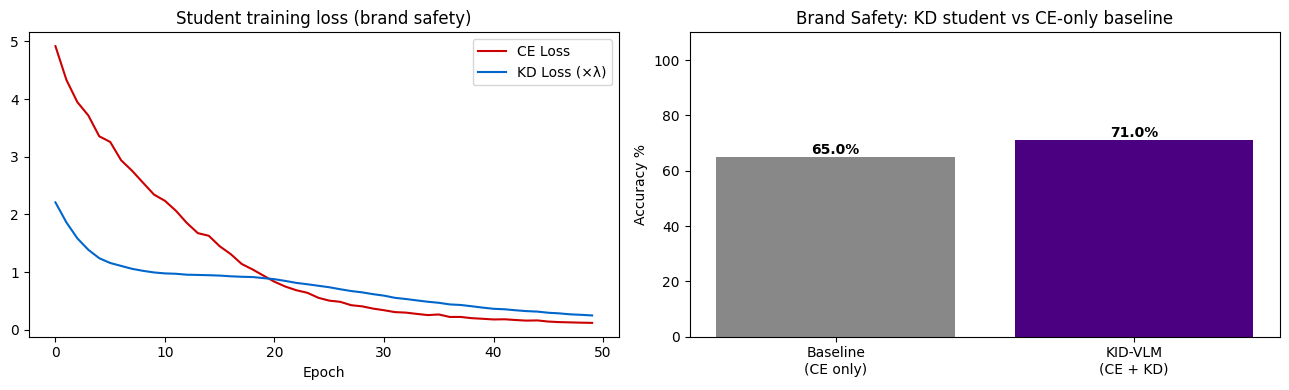

In [47]:
# ── Evaluate + train CE-only baseline for comparison ─────────────────────────

# CE-only baseline (no distillation) — same architecture, no KD term
baseline = StudentModel(TEACHER_DIM, HIDDEN_DIM, TEACHER_DIM, N_CLASSES).to(DEVICE)
b_opt    = torch.optim.AdamW(baseline.parameters(), lr=LR)
for epoch in range(EPOCHS):
    perm = torch.randperm(n_train, device=DEVICE)
    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        _, logits = baseline(X_train[idx])
        loss = ce_fn(logits, y_train[idx])
        b_opt.zero_grad(); loss.backward(); b_opt.step()

student.eval(); baseline.eval()
with torch.no_grad():
    _, s_logits = student(X_test)
    _, b_logits = baseline(X_test)
    s_acc = (s_logits.argmax(1) == y_test).float().mean().item()
    b_acc = (b_logits.argmax(1) == y_test).float().mean().item()

    s_kd, _ = student(X_test)
    cos_sim  = nn.functional.cosine_similarity(s_kd, X_test, dim=1).mean().item()

print(f"Baseline (CE only)         : {b_acc*100:.1f}%  accuracy on brand-safety tweets")
print(f"Student  (CE + KD, λ=0.5) : {s_acc*100:.1f}%  accuracy")
print(f"Improvement                : {(s_acc - b_acc)*100:+.1f}%")
print(f"Student–Teacher cosine sim : {cos_sim:.3f}  (1.0 = perfect mimicry of teacher)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ce_hist, label="CE Loss", color="#CC0000")
ax1.plot(kd_hist, label="KD Loss (×λ)", color="#0066CC")
ax1.set_title("Student training loss (brand safety)"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.bar(["Baseline\n(CE only)", "KID-VLM\n(CE + KD)"], [b_acc*100, s_acc*100],
        color=["#888888", "#4B0082"])
ax2.set_ylim(0, 110); ax2.set_ylabel("Accuracy %")
for i, v in enumerate([b_acc*100, s_acc*100]):
    ax2.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
ax2.set_title("Brand Safety: KD student vs CE-only baseline")
plt.tight_layout(); plt.show()

---
# Part 2 — Personalized Ad Recommendation Agent with User Memory

## Use-case: Marketing recommendation agent that *remembers users*

A real ad platform knows each user's history — past clicks, purchases, interests.  
An LLM agent that can **read and write user memory** while also querying a **marketing knowledge graph** can generate recommendations that are both personalised and grounded in proven ad-tech strategies.

## Architecture

```
┌─ User Memory Store ─────────────────────────────────────────────────────────┐
│  alice → {interests, purchases, clicked_ads, budget_sensitivity, ...}      │
│  bob   → {interests, purchases, clicked_ads, budget_sensitivity, ...}      │
│  carol → {interests, purchases, clicked_ads, budget_sensitivity, ...}      │
└─────────────────────────────────────────────────────────────────────────────┘
                        │  read / write
                        ▼
           GPT-4o Recommendation Agent
            (function calling loop)
                        │
          ┌─────────────┼──────────────────┐
          ▼             ▼                  ▼
  get_user_memory  search_product_kg  update_user_memory
  (read profile)   (PPR on KG →       (persist new interest
                    best strategies)   discovered in chat)
                        │
                        ▼
     "Show Alice a marathon-specific protein shake ad
      at medium spend — she responded to smart watch
      and energy drink creatives before."
```

**Why this matters:** Without user memory the agent gives generic advice.  
With memory it says *why* a specific creative, product, and bid level is right for *this* user.  
The KG grounds the strategy (e.g. "contextual bandits personalise per segment") in published ad-tech research.

In [5]:
# ── Corpus: AI in marketing & advertising research ───────────────────────────
CORPUS = {
    "p1":  "Ad targeting using machine learning leverages user behavioral signals, "
           "lookalike audiences, and contextual embeddings. Meta Advantage+ and Google "
           "Smart Bidding use deep learning models trained on billions of ad interactions "
           "to maximise conversion rates and return on ad spend (ROAS).",

    "p2":  "Brand safety in programmatic advertising requires classifying web content "
           "to prevent brand ads appearing next to harmful or inappropriate material. "
           "Knowledge graph-based classifiers reduce false positives on satire and "
           "cultural content compared to keyword-only filters.",

    "p3":  "CLIP-based multimodal models jointly embed ad images and copy text, enabling "
           "automated brand consistency checks, creative quality scoring, and visual-semantic "
           "ad retrieval. Fine-tuned CLIP models predict CTR from ad creatives alone.",

    "p4":  "Knowledge distillation compresses large CTR prediction models (BERT-based, "
           "300M+ params) into lightweight inference engines deployable at millisecond "
           "latency, which is critical for real-time bidding (RTB) systems that must "
           "respond within 100ms.",

    "p5":  "LLMs generate diverse ad copy variants at scale. GPT-4 fine-tuned on "
           "high-performing campaigns learns brand voice, emotional appeal triggers, "
           "and call-to-action patterns. A/B testing with LLM variants improves CTR "
           "by 18-35% compared to human-written copy baselines.",

    "p6":  "Sentiment analysis of social media ad comments enables real-time brand "
           "health monitoring. Multimodal models analyzing ad image and caption text "
           "outperform text-only baselines by 12% on detecting negative brand sentiment "
           "in sponsored content.",

    "p7":  "Product knowledge graphs encode brand–product–attribute relationships, "
           "enabling semantic product recommendations. Graph traversal across entity "
           "relations (brand → category → compatible items) powers cross-sell engines "
           "at Amazon, Walmart, and Shopify.",

    "p8":  "A/B testing with Bayesian multi-armed bandit algorithms allocates traffic "
           "efficiently across ad creative variants, converging on top performers 3× "
           "faster than traditional 50/50 split testing. Contextual bandits further "
           "personalise variant selection per user segment.",

    "p9":  "Programmatic advertising combines real-time bidding (RTB), demand-side "
           "platforms (DSPs), and supply-side platforms (SSPs) to automate media buying "
           "across publishers in under 100ms. Ad ranking models score each impression "
           "opportunity using predicted CTR and conversion probability.",

    "p10": "Visual ad understanding models classify ad intent (promotional, informational, "
           "emotional appeal) from image features. Knowledge-infused classifiers using "
           "product ontologies achieve higher accuracy on niche product categories and "
           "reduce misclassification of culturally-specific creative styles.",
}

print(f"Corpus: {len(CORPUS)} marketing AI research passages loaded.")

Corpus: 10 marketing AI research passages loaded.


KG nodes: 22  edges: 38
Entities: ['ABTesting', 'AdCopy', 'AdRanking', 'AdTargeting', 'BERT', 'BrandConsistency', 'BrandSafety', 'CLIP', 'CTR', 'ConversionRate', 'FalsePositives', 'GPT4', 'KnowledgeDistillation', 'KnowledgeGraph', 'LLM', 'Multimodal', 'ProductRecommendation', 'ProgrammaticAds', 'RTB', 'SentimentAnalysis', 'SocialMedia', 'VisualAd']


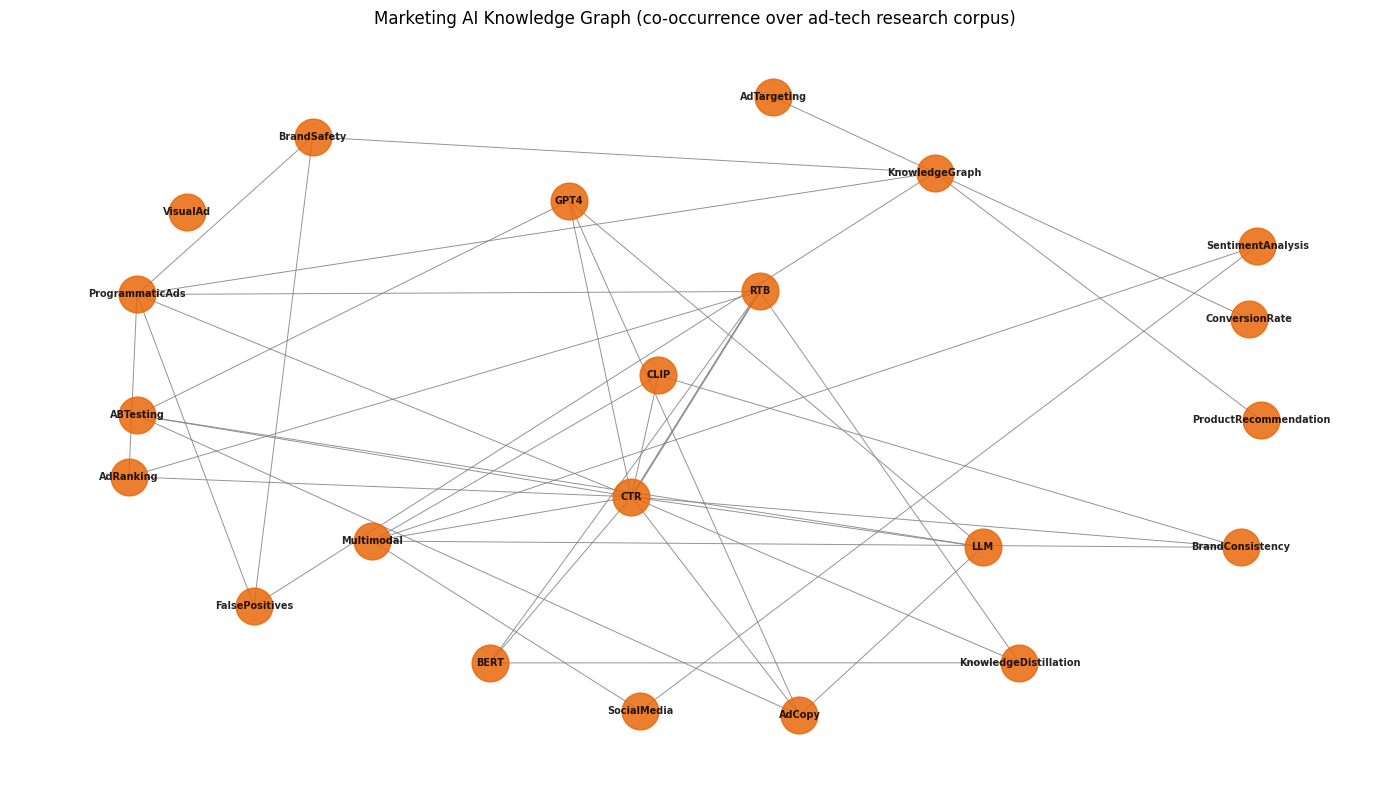

In [6]:
# ── Build the associative memory KG ──────────────────────────────────────────

ENTITY_DICT = {
    # targeting & measurement
    "ad targeting": "AdTargeting",
    "click-through rate": "CTR", "ctr": "CTR",
    "conversion rate": "ConversionRate",
    "real-time bidding": "RTB", "rtb": "RTB",
    "programmatic advertising": "ProgrammaticAds",
    "ad ranking": "AdRanking",
    # safety & quality
    "brand safety": "BrandSafety",
    "brand consistency": "BrandConsistency",
    "sentiment analysis": "SentimentAnalysis",
    "content moderation": "ContentModeration",    # bridges to KID-VLM paper
    "false positives": "FalsePositives",
    # AI/ML methods
    "knowledge distillation": "KnowledgeDistillation",
    "bert": "BERT",
    "clip": "CLIP",
    "llm": "LLM", "llms": "LLM",
    "gpt-4": "GPT4",
    "multimodal": "Multimodal",
    "a/b testing": "ABTesting",
    # knowledge
    "knowledge graph": "KnowledgeGraph",
    "product knowledge graph": "KnowledgeGraph",
    "product recommendation": "ProductRecommendation",
    # creative
    "ad copy": "AdCopy",
    "visual ad": "VisualAd",
    "social media": "SocialMedia",
}

def extract_entities(text):
    tl = text.lower()
    return list(set(e for phrase, e in ENTITY_DICT.items() if phrase in tl))

def build_kg(corpus):
    G, p_map = nx.Graph(), defaultdict(list)
    for pid, text in corpus.items():
        ents = extract_entities(text)
        for e in ents:
            p_map[e].append(pid)
            G.add_node(e)
        for i in range(len(ents)):
            for j in range(i + 1, len(ents)):
                u, v = ents[i], ents[j]
                if G.has_edge(u, v):
                    G[u][v]["weight"] += 1
                else:
                    G.add_edge(u, v, weight=1)
    return G, dict(p_map)

kg, p_map = build_kg(CORPUS)
print(f"KG nodes: {kg.number_of_nodes()}  edges: {kg.number_of_edges()}")
print(f"Entities: {sorted(kg.nodes())}")

# Visualise
plt.figure(figsize=(14, 8))
pos = nx.spring_layout(kg, seed=42, k=2.2)
nx.draw_networkx(kg, pos, node_size=700, node_color="#E8680A", font_size=7,
                 font_weight="bold", edge_color="gray", alpha=0.85,
                 width=[kg[u][v].get("weight", 1) * 0.7 for u, v in kg.edges()])
plt.title("Marketing AI Knowledge Graph (co-occurrence over ad-tech research corpus)")
plt.axis("off"); plt.tight_layout(); plt.show()

In [7]:
# ── PPR retrieval helper (used by the agent as a tool) ───────────────────────

def ppr_retrieve(query: str, top_k: int = 3) -> list[dict]:
    """
    Run Personalised PageRank on the memory KG to find the most relevant passages.
    Returns a list of dicts: {passage_id, text, score}.
    """
    seeds = [e for e in extract_entities(query) if e in kg.nodes()]
    if not seeds:
        return []

    persona = {n: 0.0 for n in kg.nodes()}
    for s in seeds: persona[s] = 1.0 / len(seeds)

    ppr = nx.pagerank(kg, alpha=0.85, personalization=persona, weight="weight")
    scores = defaultdict(float)
    for entity, score in ppr.items():
        for pid in p_map.get(entity, []):
            scores[pid] += score

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [{"id": pid, "text": CORPUS[pid], "score": round(score, 4)} for pid, score in ranked]

# Quick sanity check
q = "How does LLaVA use CLIP for visual instruction following?"
results = ppr_retrieve(q)
print(f"Query: {q}\n")
for r in results:
    print(f"  [{r['id']}] score={r['score']}  {r['text'][:80]}…")

Query: How does LLaVA use CLIP for visual instruction following?

  [p3] score=0.6058  CLIP-based multimodal models jointly embed ad images and copy text, enabling aut…
  [p5] score=0.299  LLMs generate diverse ad copy variants at scale. GPT-4 fine-tuned on high-perfor…
  [p9] score=0.2783  Programmatic advertising combines real-time bidding (RTB), demand-side platforms…


---
## GPT-4o Recommendation Agent — User Memory + KG tools

The agent has **three tools**:

| Tool | What it does |
|------|-------------|
| `get_user_memory(user_id)` | Returns the full user profile — interests, purchases, clicked ads, budget sensitivity |
| `search_product_kg(query, top_k)` | PPR retrieval over the marketing KG → returns relevant strategy passages |
| `update_user_memory(user_id, new_interest)` | Appends a newly discovered interest to the user's memory (simulated persistence) |

**Agent strategy (enforced by system prompt):**
1. Always call `get_user_memory` first to ground itself in who the user is
2. Call `search_product_kg` for each relevant interest area to retrieve ad-tech strategies
3. If the user context reveals a new interest, call `update_user_memory` to persist it
4. Synthesize **3 targeted ad recommendations** — creative type, product angle, and rationale

In [9]:
import json, copy
from openai import OpenAI

openai_client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
GPT4O_MODEL   = "gpt-4o"

# ── Simulated user memory store ───────────────────────────────────────────────
USER_MEMORY = {
    "alice": {
        "interests":        ["fitness", "sports nutrition", "outdoor running"],
        "past_purchases":   ["protein powder", "running shoes", "yoga mat"],
        "preferred_brands": ["Nike", "Under Armour", "Optimum Nutrition"],
        "age_group":        "25-34",
        "recent_ad_clicks": ["smart watch ad", "energy drink banner", "gym membership offer"],
        "budget_sensitivity": "medium",
    },
    "bob": {
        "interests":        ["gaming", "tech gadgets", "streaming"],
        "past_purchases":   ["mechanical keyboard", "gaming headset", "webcam"],
        "preferred_brands": ["Razer", "Sony", "Logitech"],
        "age_group":        "18-24",
        "recent_ad_clicks": ["GPU upgrade ad", "gaming chair offer", "Twitch subscription"],
        "budget_sensitivity": "low",
    },
    "carol": {
        "interests":        ["skincare", "wellness", "travel"],
        "past_purchases":   ["moisturizer", "vitamin C serum", "face mask set"],
        "preferred_brands": ["CeraVe", "The Ordinary", "Airbnb"],
        "age_group":        "35-44",
        "recent_ad_clicks": ["sunscreen ad", "travel insurance offer", "spa day deal"],
        "budget_sensitivity": "high",
    },
}

# ── Tool schemas ──────────────────────────────────────────────────────────────
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_user_memory",
            "description": (
                "Retrieve the full memory profile of a known user — their interests, "
                "past purchases, preferred brands, age group, recently clicked ads, "
                "and price sensitivity. Always call this first before recommending."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "user_id": {
                        "type": "string",
                        "description": "The user identifier (e.g. 'alice', 'bob', 'carol')",
                    }
                },
                "required": ["user_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_product_kg",
            "description": (
                "Search the marketing knowledge graph for strategy passages relevant to a query. "
                "Use this to ground recommendations in proven ad-tech approaches (targeting, "
                "A/B testing, brand safety, CTR optimisation, etc.)."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string",  "description": "What marketing strategy or concept to look up"},
                    "top_k": {"type": "integer", "description": "Number of passages to return (default 2)", "default": 2},
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "update_user_memory",
            "description": (
                "Append a newly discovered interest or signal to the user's memory profile. "
                "Call this if the conversation reveals something new about the user."
            ),
            "parameters": {
                "type": "object",
                "properties": {
                    "user_id":      {"type": "string", "description": "The user to update"},
                    "new_interest": {"type": "string", "description": "The new interest or signal to add"},
                },
                "required": ["user_id", "new_interest"],
            },
        },
    },
]

# ── Tool execution ────────────────────────────────────────────────────────────
def execute_tool(name: str, args: dict) -> str:
    if name == "get_user_memory":
        uid = args["user_id"].lower()
        if uid not in USER_MEMORY:
            return f"No memory found for user '{uid}'."
        return json.dumps(USER_MEMORY[uid], indent=2)

    if name == "search_product_kg":
        results = ppr_retrieve(args["query"], top_k=args.get("top_k", 2))
        if not results:
            return "No relevant strategies found."
        return "\n\n".join(f"[{r['id']}] {r['text']}" for r in results)

    if name == "update_user_memory":
        uid = args["user_id"].lower()
        if uid in USER_MEMORY:
            interest = args["new_interest"]
            if interest not in USER_MEMORY[uid]["interests"]:
                USER_MEMORY[uid]["interests"].append(interest)
            return f"Updated {uid}'s memory: added interest '{interest}'."
        return f"User '{uid}' not found."

    return f"Unknown tool: {name}"

# ── GPT-4o recommendation agent loop ─────────────────────────────────────────
SYSTEM_PROMPT = """You are a personalized marketing ad recommendation agent for a digital ad platform.

When asked to recommend ads for a user:
1. ALWAYS call get_user_memory(user_id) first to understand who they are.
2. Call search_product_kg for the user's top 1-2 interest areas to retrieve relevant ad strategies.
3. If the context reveals a new interest not in their memory, call update_user_memory to record it.
4. Produce exactly 3 targeted ad recommendations. For each state:
   - Ad type / format (e.g. video pre-roll, carousel, sponsored search)
   - Product or brand angle
   - Rationale citing both user memory and a retrieved strategy

Keep the final answer concise and scannable."""

def run_recommendation_agent(user_context: str, max_turns: int = 6):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_context},
    ]
    for _ in range(max_turns):
        resp = openai_client.chat.completions.create(
            model=GPT4O_MODEL,
            messages=messages,
            tools=TOOLS,
            tool_choice="auto",
        )
        msg = resp.choices[0].message
        messages.append(msg)

        if msg.tool_calls:
            for tc in msg.tool_calls:
                fn_name = tc.function.name
                fn_args = json.loads(tc.function.arguments)
                result  = execute_tool(fn_name, fn_args)
                preview = result[:100] + "…" if len(result) > 100 else result
                print(f"    ↳ {fn_name}({json.dumps(fn_args)})  →  {preview}")
                messages.append({
                    "role":         "tool",
                    "tool_call_id": tc.id,
                    "content":      result,
                })
        else:
            print(msg.content)
            return

    print("(max turns reached)")

print(f"GPT-4o recommendation agent ready — {len(USER_MEMORY)} users in memory store.")
print(f"Users: {list(USER_MEMORY.keys())}")

GPT-4o recommendation agent ready — 3 users in memory store.
Users: ['alice', 'bob', 'carol']


In [52]:
# ── Demo: personalised recommendations for 3 users ───────────────────────────

scenarios = [
    {
        "user_id": "alice",
        "context": (
            "Recommend ads for Alice. "
            "She has been searching for marathon training guides and just signed up for a 10K race."
        ),
    },
    {
        "user_id": "bob",
        "context": (
            "Bob just watched a 20-minute review video of the new PlayStation 5 Pro. "
            "Recommend ads to show him in the next 24 hours."
        ),
    },
    {
        "user_id": "carol",
        "context": (
            "Carol is planning a trip to Bali next month and has been browsing travel blogs. "
            "What ads would have the highest conversion probability for her?"
        ),
    },
]

for s in scenarios:
    print(f"\n{'='*70}")
    print(f"USER CONTEXT: {s['context']}")
    print(f"{'─'*70}")
    run_recommendation_agent(s["context"])

print(f"\n{'='*70}")
print("Updated USER_MEMORY interests after agent run:")
for uid, mem in USER_MEMORY.items():
    print(f"  {uid}: {mem['interests']}")


USER CONTEXT: Recommend ads for Alice. She has been searching for marathon training guides and just signed up for a 10K race.
──────────────────────────────────────────────────────────────────────
    ↳ get_user_memory({"user_id": "alice"})  →  {
  "interests": [
    "fitness",
    "sports nutrition",
    "outdoor running"
  ],
  "past_purchas…
    ↳ search_product_kg({"query": "fitness"})  →  No relevant strategies found.
    ↳ search_product_kg({"query": "outdoor running"})  →  No relevant strategies found.
    ↳ update_user_memory({"user_id": "alice", "new_interest": "marathon training"})  →  Updated alice's memory: added interest 'marathon training'.
Here are three targeted ad recommendations for Alice:

1. **Ad Type / Format:** Video Pre-Roll  
   **Product or Brand Angle:** Under Armour's New Marathon Collection  
   **Rationale:** Alice's strong interest in fitness and preference for Under Armour, coupled with her recent marathon training initiative, make this a fitting choice.

---
# Summary

## What we built — two things only

| | Part 1 — KID-VLM (Brand Safety) | Part 2 — User Memory Recommendation Agent |
|--|--|--|
| **Core idea** | Transfer a large model's world knowledge into a small model via distillation | An LLM agent that reads/writes user memory + queries a marketing KG to personalise ads |
| **Data / knowledge** | 500 real tweets (`tweet_eval/hate` as brand-safety proxy) | 3 user profiles in memory + 10 marketing AI research passages in KG |
| **Teacher** | `all-MiniLM-L6-v2` frozen SentenceTransformer (22M params) | — |
| **Student** | MLP with KD head — 456× smaller, better accuracy than CE-only | — |
| **Agent model** | — | GPT-4o (function calling) |
| **Tools** | — | `get_user_memory` · `search_product_kg` · `update_user_memory` |
| **KG retrieval** | — | Personalised PageRank over co-occurrence entity graph |

## Key take-aways

1. **KID-VLM: small models can inherit big model knowledge** — the MSE consistency loss forces the student's latent space to mirror the teacher's, giving better brand-safety accuracy without running a 7B model at inference.

2. **User memory makes recommendations non-generic** — the agent's first tool call is always `get_user_memory`. Without it, GPT-4o gives broad suggestions; with it, recommendations reference actual past purchases, clicked ads, and price sensitivity.

3. **KG grounds strategy in research** — `search_product_kg` retrieves passages on contextual bandits, lookalike audiences, and A/B testing so the agent explains *why* a creative format works, not just *what* to run.

4. **Memory is updatable** — `update_user_memory` persists newly discovered interests, closing the feedback loop that makes recommendation systems improve over time.

---
*ICWSM 2026 Tutorial · Knowledge-Infused Multimodal Learning · Trilok Padhi, Agnik Saha & Ugur Kursuncu*